# All certain channels except for one

## 1. Descriptions
In this experiment, let's assume that we have known the performance of 3 out of 4 channels in the study with very high certainty. However, we are not quite sure about the performance of Channel 0. Let's study how the Bayesian experimental design (BED) framework can help strengthen our knowledge and reduce our uncertainty.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl
import polars.selectors as cs
from bedmmm.data.generator import DataGenerator
from bedmmm.experiment_designer import ExperimentDesigner
from bedmmm.model import MarketingMixModel
from thesis.plot import (
    plot_experiment_posterior_response_curve,
    plot_experiment_posterior_vs_ground_truth,
    plot_generated_data_on_response_curve,
    plot_posterior_response_curve,
    plot_posterior_vs_ground_truth,
)

In [2]:
plt.rcParams.update(
    {
        "font.size": 18,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "legend.fontsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 2. Synthetic Data Generation

In [3]:
np.random.seed(10)
generator = (
    DataGenerator(
        n_time_periods=52,  # weeks
        n_future_periods=4,
    )
    .generate_baseline(
        base=10,
        noise=0.0,
    )
    # Seasonality generated using sine wave
    .generate_control(
        control_effect=1,
        noise=1,
    )
    # 1. Low retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.2,
        saturation=5,
        shape=3,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 2. Low retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.2,
        saturation=2,
        shape=1,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 3. High retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.8,
        saturation=6,
        shape=3,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 4. High retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.8,
        saturation=2,
        shape=1,
        metric_lower_bound=2,
        noise=1.0,
    )
    .generate_target(noise=3)
)

data = generator.collect()
media_param_df, control_param_df = generator.get_parameters()

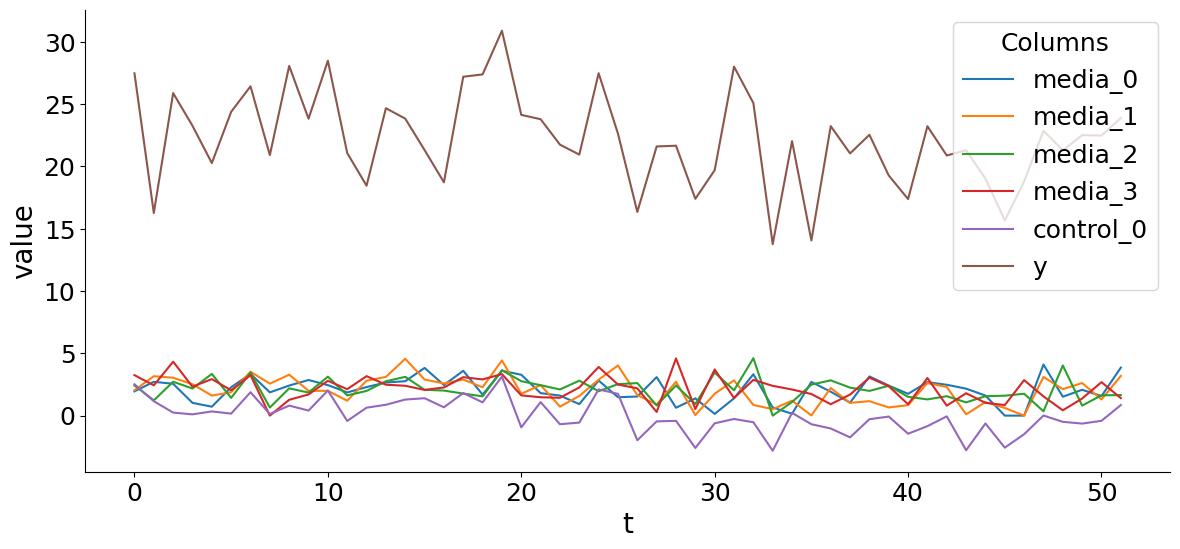

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

for column in data.columns:
    ax.plot(
        data.with_row_index("time_index")["time_index"],
        data[column],
        label=column,
    )

ax.set_xlabel("t")
ax.set_ylabel("value")
ax.legend(title="Columns")

plt.show()

Let's show where on the response curves the generated media data is:

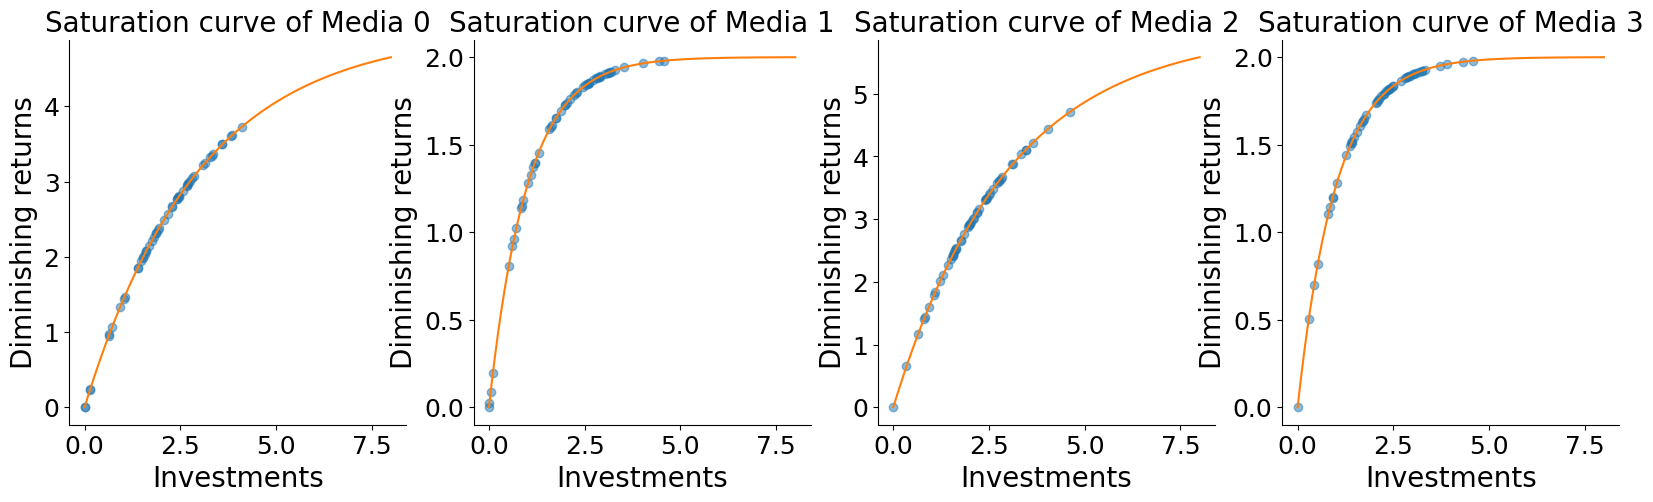

In [5]:
plot_generated_data_on_response_curve(data, media_param_df)

## 3. Fit a Marketing Mix Model (MMM)

Let's fit a MMM where the prior distributions of the Media channel 0 are chosen to reflect the high uncertainty while the prior distributions of all other channels are tight.

In [6]:
model_config = {
    #
    # Media channel 0 priors (high uncertainty)
    "retention_rate_lb_0": 0.1,
    "retention_rate_ub_0": 0.9,
    "shape_mu_0": 3,
    "shape_sigma_0": 2,
    "saturation_mu_0": 5,
    "saturation_sigma_0": 2,
    #
    # Media channel 1 priors (tight priors)
    "retention_rate_lb_1": 0.19,
    "retention_rate_ub_1": 0.21,
    "shape_mu_1": 1,
    "shape_sigma_1": 0.1,
    "saturation_mu_1": 2,
    "saturation_sigma_1": 0.1,
    #
    # Media channel 2 priors (tight priors)
    "retention_rate_lb_2": 0.79,
    "retention_rate_ub_2": 0.81,
    "shape_mu_2": 3,
    "shape_sigma_2": 0.1,
    "saturation_mu_2": 6,
    "saturation_sigma_2": 0.1,
    #
    # Media channel 3 priors (tight priors)
    "retention_rate_lb_3": 0.79,
    "retention_rate_ub_3": 0.81,
    "shape_mu_3": 1,
    "shape_sigma_3": 0.1,
    "saturation_mu_3": 2,
    "saturation_sigma_3": 0.1,
    #
    # Control
    "gamma_mu_0": 1.0,
    "gamma_sigma_0": 1.0,
    #
    # Baseline
    "baseline_mu": 10.0,
    "baseline_sigma": 0.1,
    #
    # Observation noise
    "obs_sigma": 3,
}
sampler_config = {
    "draws": 15_000,
    "tune": 5_000,
    "chains": 4,
    "cores": 4,
    "target_accept": 0.95,
}

model = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

In [7]:
idata = model.fit(
    data.drop(["y"]).to_pandas(),
    data["y"].to_pandas(),
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 157 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [8]:
summary_df = az.summary(idata)
# az.plot_trace(idata, figsize=(15, 20));

### 3.1 Comparison between Posterior Distributions and Ground Truth

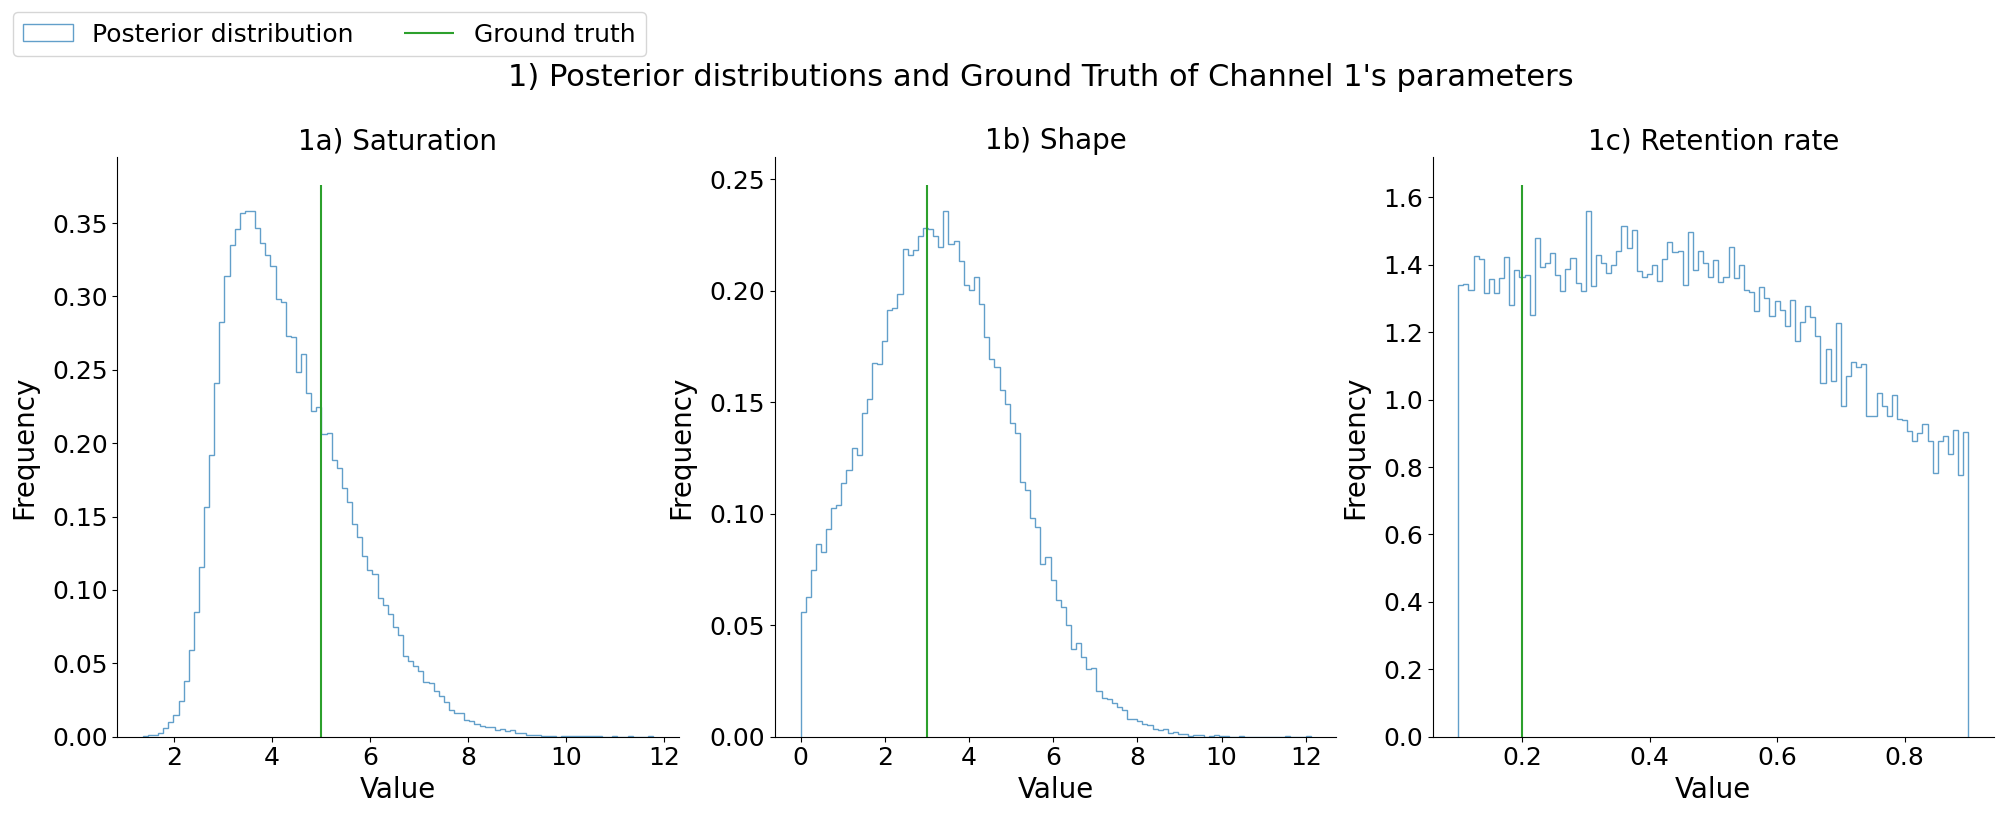

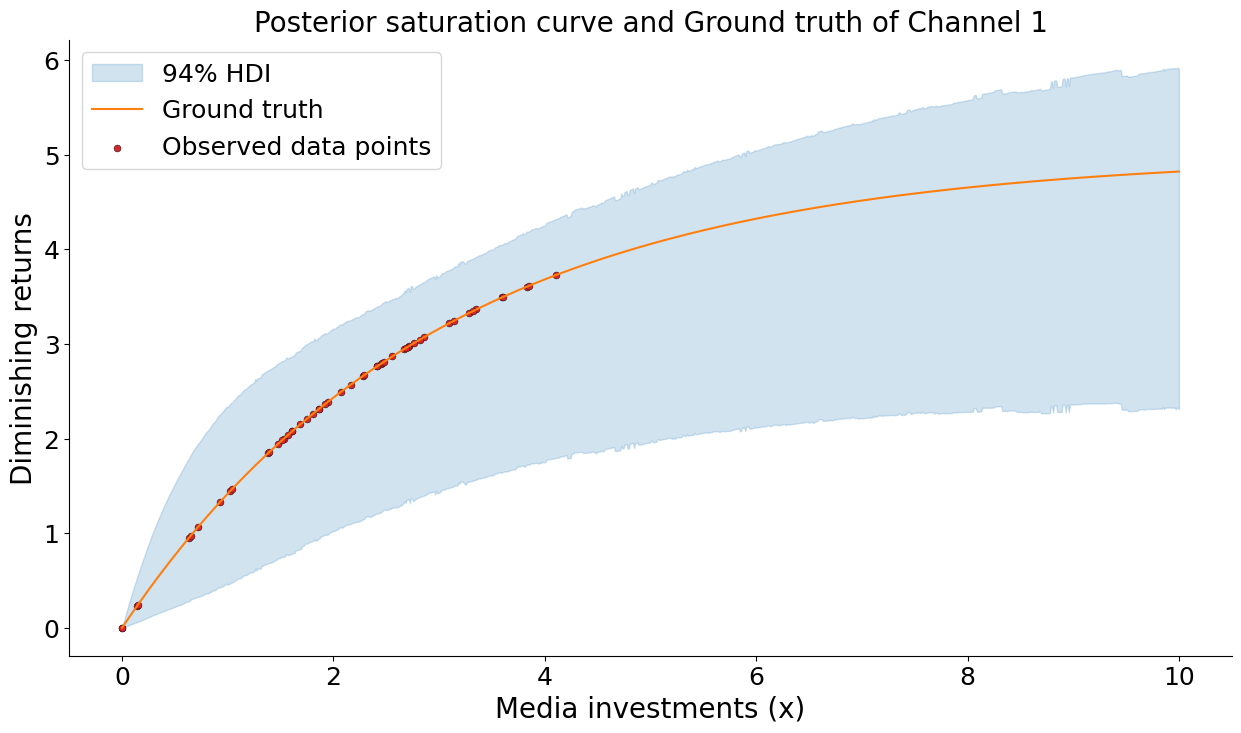

In [9]:
plot_posterior_vs_ground_truth(
    idata, media_param_df, media_feature_names=["media_0"]
)

plot_posterior_response_curve(
    idata, data, media_param_df, media_feature_name="media_0"
)

## 4. Bayesian Experiment Design (BED)

When generating the synthetic data, a dataset, which we call "future data", is also generated along with the data used to fit the model above. "Future data" is not used to fit the model but considered as the budget planning for marketing investments. This helps us quantify the difference between the investments recommended in the optimal experiment and the planned budget (which the marketers are already comfortable of investing).

In [10]:
future_data = generator.collect(data_type="future")
future_control_vars = (
    future_data.slice(0, 1)
    .select(cs.starts_with("control_"))
    .to_numpy()
    .flatten()
)
future_media_data = (
    future_data.slice(0, 1)
    .select(cs.starts_with("media_"))
    .to_numpy()
    .flatten()
)

In [11]:
future_media_data

array([1.41826055, 3.03774116, 2.5643959 , 3.32363377])

### 4.1 Optimize for response curve parameters

In [12]:
d_hat_curve_param = (
    ExperimentDesigner(n_media_channels=4, c=future_control_vars)
    .add_posterior_samples(idata)
    .configure_experiment_space(
        # Let's assume that we only do the experimnent on the Channel 0.
        lower_bound=np.concatenate([[0], future_media_data[1:]]),
        upper_bound=np.concatenate([[100], future_media_data[1:]]),
    )
    # .configure_regularization(
    #     x_0=future_media_data,
    #     regularized_type="cost",
    #     regularized_weight=0.1,
    # )
    .configure_target_variables(
        [
            "saturation",
            "shape",
            # "retention_rate",
        ]
    )
    .find_optimal_experiment()
)
print(f"Optimal experiment found for curve parameters: {d_hat_curve_param}")

# Add the experiment data to the synthetic generated dataset
generator_with_dhat_curve_param = (
    generator
    #
    .generate_new_observation(x=d_hat_curve_param, c=future_control_vars)
)
data_with_dhat_curve_param = generator_with_dhat_curve_param.collect()

# Fit the model again with the new data including the experiment
model_with_dhat_curve_param = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)
idata_with_dhat_curve_param = model_with_dhat_curve_param.fit(
    data_with_dhat_curve_param.drop(["y"]).to_pandas(),
    data_with_dhat_curve_param["y"].to_pandas(),
    random_seed=42,
)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -0.03609839101605686
        x: [ 4.433e+01  3.038e+00  2.564e+00  3.324e+00]
      nit: 7
      jac: [-6.558e-06        nan        nan        nan]
     nfev: 30
     njev: 15
 hess_inv: None
Optimal experiment found for curve parameters: [44.32606994  3.03774116  2.5643959   3.32363377]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 134 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [13]:
# Summary results
summary_with_dhat_curve_param_df = az.summary(idata_with_dhat_curve_param)
# az.plot_trace(idata_with_dhat, figsize=(15, 20));

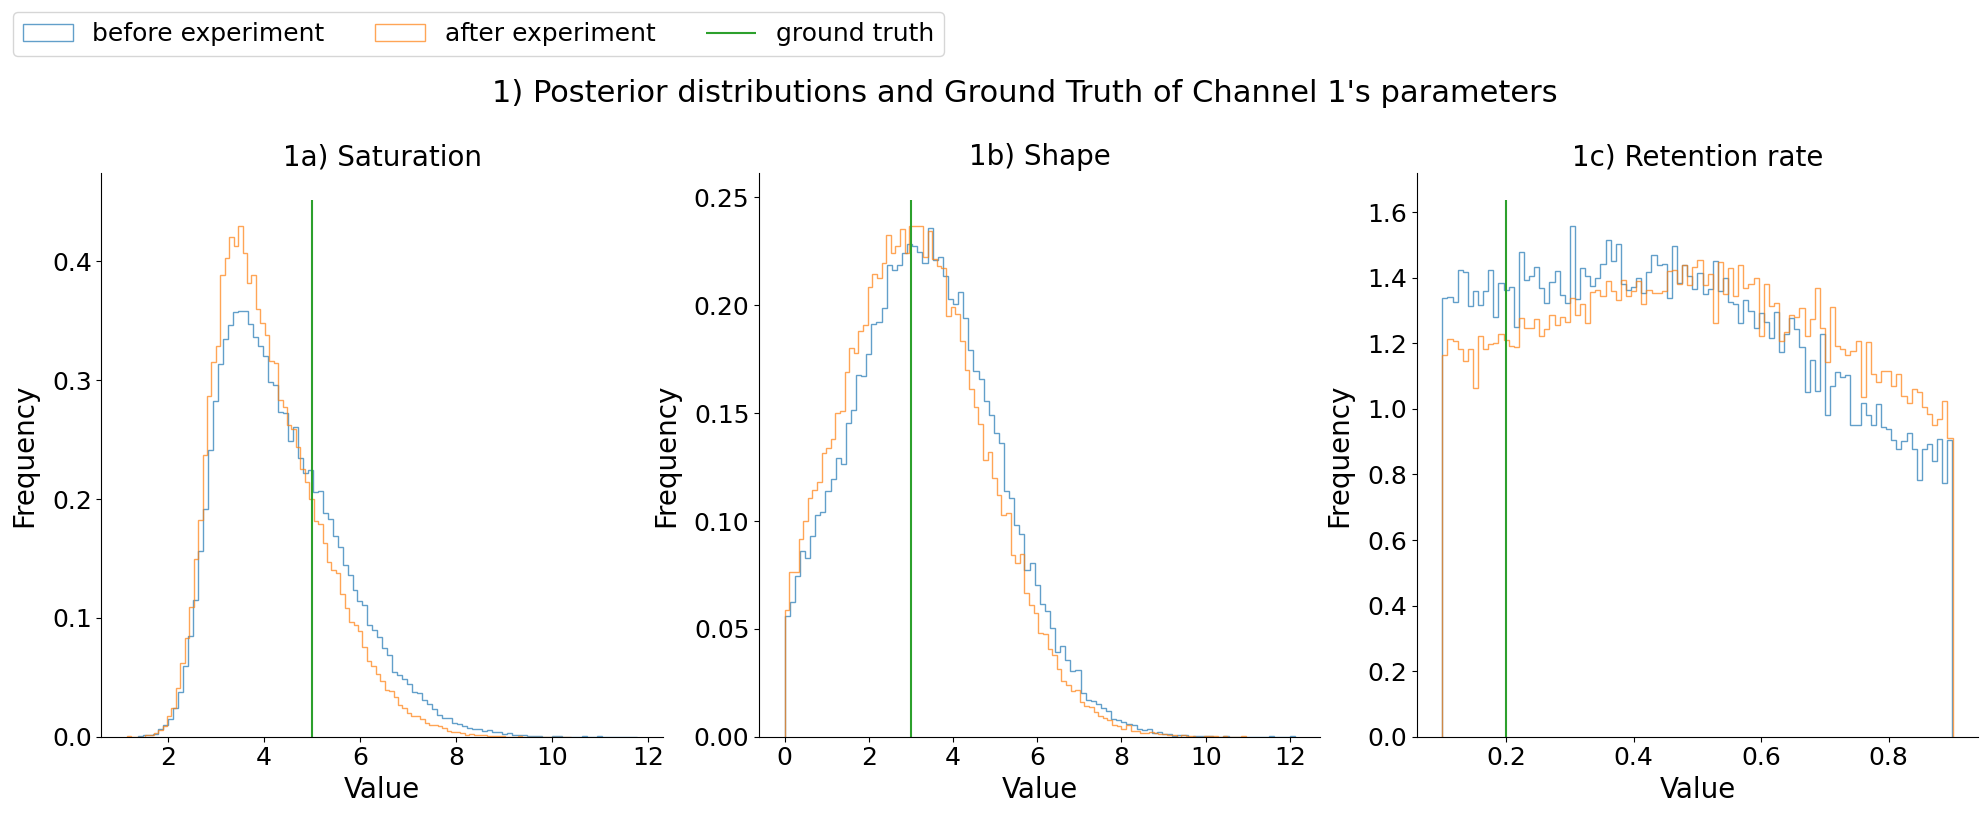

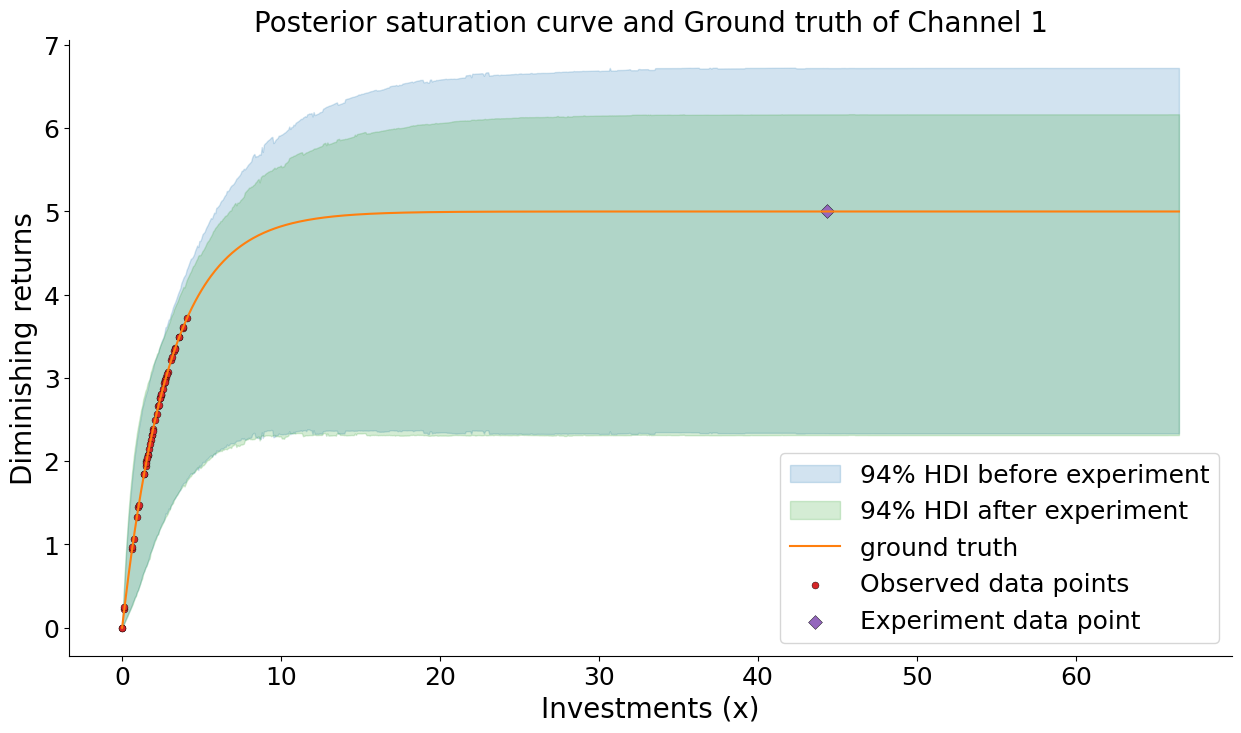

In [14]:
# Plot the stuff
plot_experiment_posterior_vs_ground_truth(
    idata_before_experiment=idata,
    idata_after_experiment=idata_with_dhat_curve_param,
    media_param_df=media_param_df,
    media_feature_names=["media_0"],
)

plot_experiment_posterior_response_curve(
    idata_before_experiment=idata,
    idata_after_experiment=idata_with_dhat_curve_param,
    data=data,
    experiment_data=d_hat_curve_param,
    media_param_df=media_param_df,
    media_feature_name="media_0",
)

### 4.2 Optimize for retention rate parameter

In [15]:
d_hat_retention_rate = (
    ExperimentDesigner(n_media_channels=4, c=future_control_vars)
    .add_posterior_samples(idata)
    .configure_experiment_space(
        # Let's assume that we only do the experimnent on the Channel 0.
        lower_bound=np.concatenate([[0], future_media_data[1:]]),
        upper_bound=np.concatenate([[100], future_media_data[1:]]),
    )
    # .configure_regularization(
    #     x_0=future_media_data,
    #     regularized_type="cost",
    #     regularized_weight=0.1,
    # )
    .configure_target_variables(
        [
            # "saturation",
            # "shape",
            "retention_rate",
        ]
    )
    .find_optimal_experiment()
)
print(
    f"Optimal experiment found for retention rate parameter: "
    f"{d_hat_retention_rate}"
)

# Add the experiment data to the synthetic generated dataset
generator_with_dhat_retention_rate = (
    generator
    #
    .generate_new_observation(x=d_hat_retention_rate, c=future_control_vars)
)
data_with_dhat_retention_rate = generator_with_dhat_retention_rate.collect()

# Fit the model again with the new data including the experiment
model_with_dhat_retention_rate = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)
idata_with_dhat_retention_rate = model_with_dhat_retention_rate.fit(
    data_with_dhat_retention_rate.drop(["y"]).to_pandas(),
    data_with_dhat_retention_rate["y"].to_pandas(),
    random_seed=42,
)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -0.013530428768095893
        x: [ 7.337e-17  3.038e+00  2.564e+00  3.324e+00]
      nit: 2
      jac: [ 1.401e-02        nan        nan        nan]
     nfev: 14
     njev: 7
 hess_inv: None
Optimal experiment found for retention rate parameter: [7.33713197e-17 3.03774116e+00 2.56439590e+00 3.32363377e+00]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 139 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [16]:
# Summary results
summary_with_dhat_retention_rate_df = az.summary(
    idata_with_dhat_retention_rate
)
# az.plot_trace(idata_with_dhat, figsize=(15, 20));


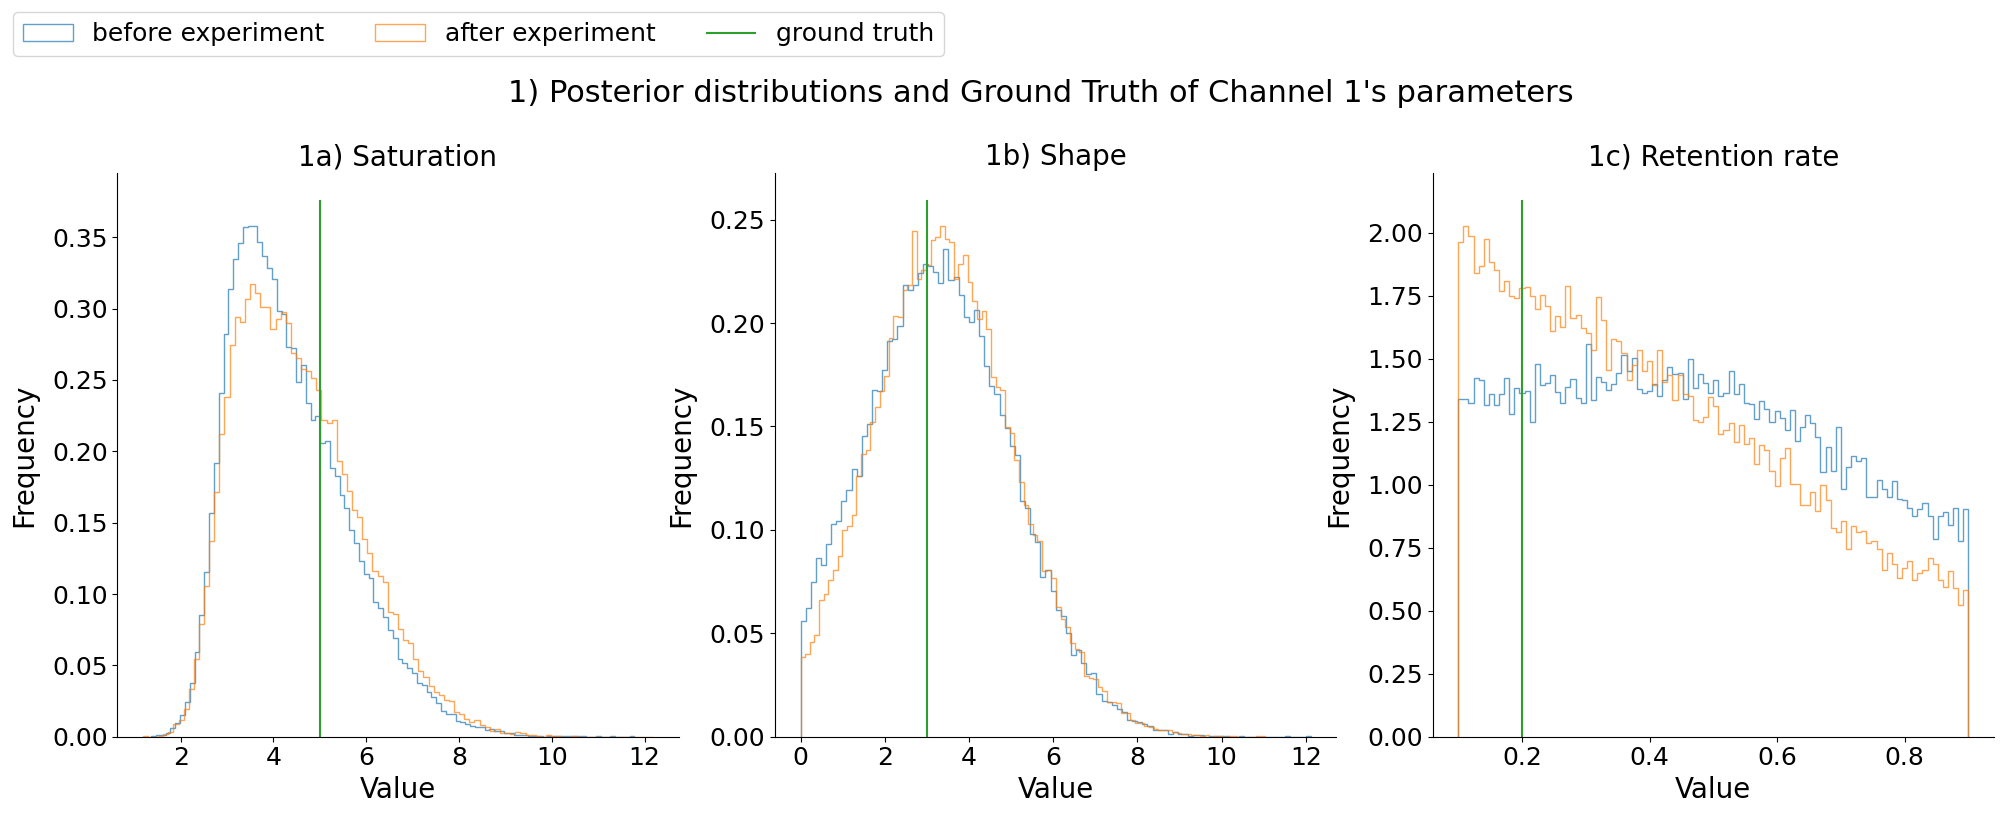

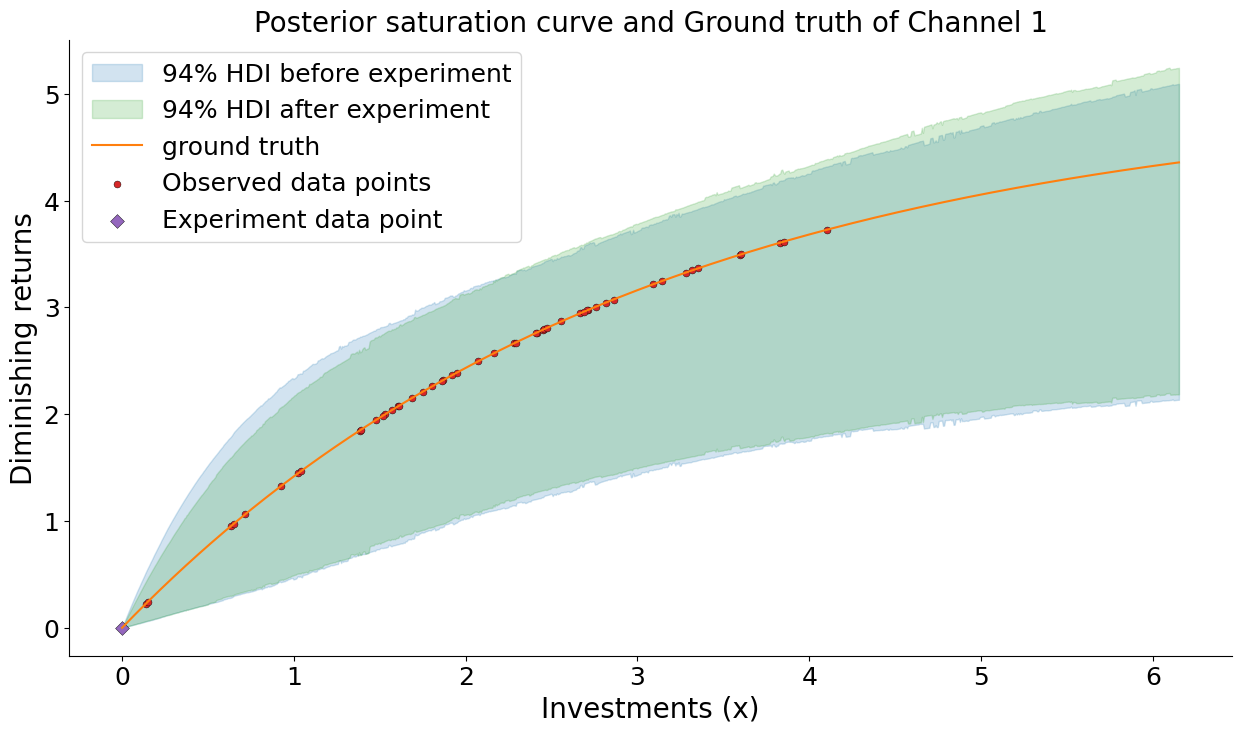

In [17]:
# Plot the stuff
plot_experiment_posterior_vs_ground_truth(
    idata_before_experiment=idata,
    idata_after_experiment=idata_with_dhat_retention_rate,
    media_param_df=media_param_df,
    media_feature_names=["media_0"],
)

plot_experiment_posterior_response_curve(
    idata_before_experiment=idata,
    idata_after_experiment=idata_with_dhat_retention_rate,
    data=data,
    experiment_data=d_hat_retention_rate,
    media_param_df=media_param_df,
    media_feature_name="media_0",
)